In [2]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

#X_digits, y_digits = datasets.load_digits(return_X_y = True)
digits = load_digits()
X_digits, y_digits = digits.data, digits.target
print(X_digits)
print(y_digits)

[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]
[0 1 2 ... 8 9 8]


El dataset tiene imagenes de numeros escritos a mano del 0 al 9, de 8x8 pixeles 

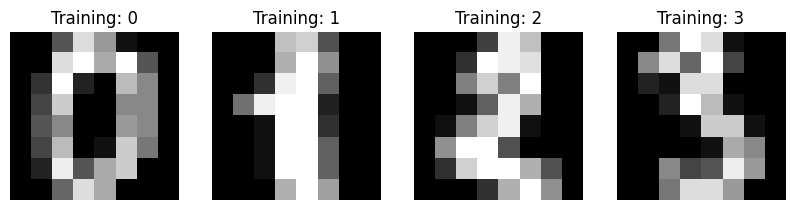

In [3]:
_, axes = plt.subplots(1, 4, figsize=(10, 4))

for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap=plt.cm.gray, interpolation="nearest")  # cada imagen es 8x8
    ax.set_title(f"Training: {digits.target[i]}")  # el valor real
    ax.axis("off")  # sacar los ejes para que se vea más limpio

plt.show()

ACC: 0.9528619528619529


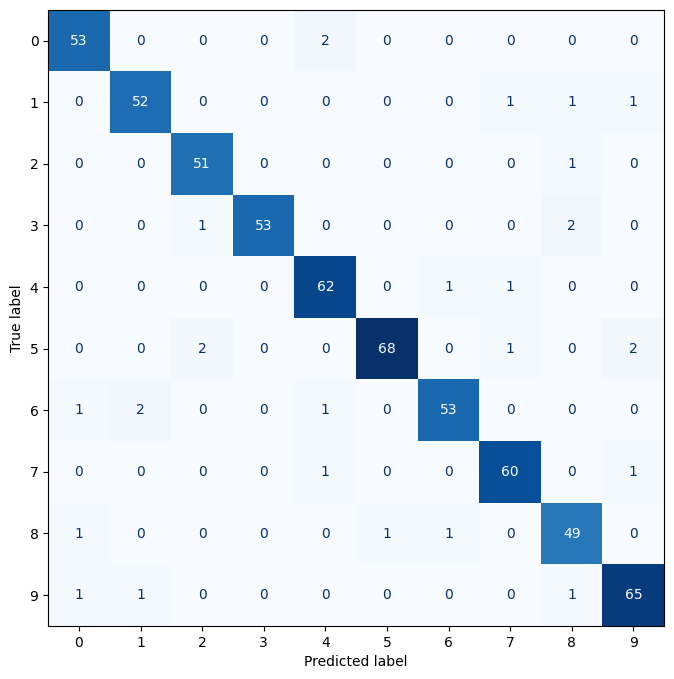

In [4]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.datasets import datasets


#Particionamiento de los datos
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, test_size=0.33, random_state=42)
#Basicamente separamos los datos en 67% para entrenamiento y 33% para testeo usando el split
#una sola subdivisión del dataset en entrenamiento y prueba. Estimás el error de generalización con un único corte (puede tener varianza alta si “tocó” un corte desafortunado).

#Definicion del modelo
clf = MLPClassifier(hidden_layer_sizes=(20,10), learning_rate_init=0.005, max_iter=300, activation='logistic',
                     early_stopping= True, validation_fraction=0.3, shuffle=True, random_state=0)

#Basicamente una red neuronal con 2 capas ocultas, la primera con 20 neuronas y la segunda con 10 neuronas,
#usando la funcion de activacion logistica que es como una sigmoide
#Tasa de aprendizaje de 0.005 y un maximo de 300 iteraciones o epocas
#Usamos early stopping para evitar overfitting, con un 30% de los datos
#para validacion y shuffle para mezclar los datos antes de cada epoca


#Entrenamos el modelo
clf.fit(X_train, y_train)
#Evaluacion del modelo
y_pred = clf.predict(X_test)

#Calculo de metricas
ACC = accuracy_score(y_test, y_pred) ##Porcentaje de aciertos
MC = confusion_matrix(y_test, y_pred, labels=digits.target_names)

disp = ConfusionMatrixDisplay(confusion_matrix = MC, display_labels = digits.target_names)
fig, ax = plt.subplots(figsize = (8,8))
disp.plot(ax=ax, cmap ="Blues", values_format='', colorbar=None)
print('ACC:', ACC)
plt.show()

## Matriz de confusion

Es una tabla que compara las predicciones del modelo con los valores reales.
Filas = valores reales.
Columnas = valores predichos.
Diagonal = aciertos.
Fuera de la diagonal = errores (confusiones entre clases).

Sirve para ver qué tan bien clasifica el modelo y en qué clases se equivoca.

# KFold's = 5

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate
from sklearn.model_selection import train_test_split, KFold, cross_val_score


n_folds = 5

kf = KFold(n_splits = n_folds, shuffle = True)

#lista de listas para guardar metricas por clasificador por fold
ACC = [[] for i in range(9)]  #guardamos la proporcion de predicciones correctas (predicciones correctas / predicciones totales)

for i, (train_index, test_index) in enumerate(kf.split(X_digits)):
    X_train, y_train, X_test, y_test = X_digits[train_index], y_digits[train_index], X_digits[test_index], y_digits[test_index]

    scaler = StandardScaler()
    scaler.fit(X_train)   #Calcula la media y desviación estándar solo con los datos de entrenamiento
    X_train = scaler.transform(X_train)  #Alica esa transformación al set de entrenamiento.
    X_test = scaler.transform(X_test)   #Aplica la misma transformación al set de prueba (usando los parámetros del entrenamiento).

    #Así se evita que una variable con valores grandes domine sobre las demás
    
    # ------------------ MLP ------------------
    clf = MLPClassifier(
        hidden_layer_sizes=(20,10,5),           # Capas ocultas con 20 y 10 neuronas
        learning_rate_init=0.005,             # Tasa de aprendizaje inicial
        max_iter=300,                          # Máximo número de iteraciones
        activation='logistic',                 # Función de activación sigmoide
        early_stopping=True,                   # Detener si no mejora en validación
        validation_fraction=0.3,              # Fracción de validación para early stopping
        shuffle=True,
        random_state=0
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[0].append(acc)

    # ------------------ Naive Bayes ------------------
    bayes = GaussianNB()
    bayes.fit(X_train, y_train)
    y_pred = bayes.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[1].append(acc)

    # ------------------ SVM LINEAR ------------------
    clf = svm.SVC(kernel='linear', C=1, gamma='auto')  
    # kernel='linear' → busca un hiperplano recto
    # C=1 → regularización
    # gamma='auto' → ignorado en lineal
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[2].append(acc)

    # ------------------ SVM POLINOMIAL ------------------
    clf = svm.SVC(kernel='poly', degree=2, coef0=1, gamma='auto')
    # kernel='poly' → polinomio
    # degree=2 → grado del polinomio
    # coef0=1 → ajuste del término independiente
    # gamma='auto' → alcance de influencia de cada punto
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[3].append(acc)

    # ------------------ SVM RBF ------------------
    clf = svm.SVC(kernel='rbf', C=1, gamma='auto')
    # kernel='rbf' → frontera curva (gaussiana)
    # C=1 → regularización
    # gamma='auto' → controla alcance de cada punto
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[4].append(acc)

    # ------------------ SVM SIGMOID ------------------
    clf = svm.SVC(kernel='sigmoid', C=1, gamma='auto')
    # kernel='sigmoid' → similar a una neurona con función sigmoide
    # C=1 → regularización
    # gamma='auto' → controla alcance de cada punto
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[5].append(acc)


    # ------------------ LDA (Linear Discriminant Analysis) hay que ver ------------------
    clf = LinearDiscriminantAnalysis()
    # LDA busca proyectar los datos a un espacio donde las clases estén lo más separadas posible
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[6].append(acc)

    # ------------------ K-Vecinos (KNN) ------------------
    clf = KNeighborsClassifier(n_neighbors=7)
    # n_neighbors=5 → clasifica cada punto según la mayoría de sus 5 vecinos más cercanos
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[7].append(acc)

    # ------------------ Árbol de decisión ------------------
    clf = DecisionTreeClassifier(random_state=70)
    # random_state=4 → asegura reproducibilidad
    # Crea un árbol que divide el espacio de características para separar las clases
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[8].append(acc)

# ------------------ Convierte la lista de accuracies en un array ------------------
ACC = np.array(ACC)
# ACC tiene forma (n_modelos, n_iteraciones) → cada fila = un clasificador, cada columna = una corrida/fold




# ------------------ Calcula media y desviación estándar ------------------
acc_mean = np.mean(ACC, axis=1)  # Promedio de accuracy por clasificador
acc_std = np.std(ACC, axis=1)    # Desviación estándar de accuracy por clasificador

# Nombres de los clasificadores en el mismo orden que ACC
classifiers = ["Multicapa", "NaiveBayes", "SVM-linear", "SVM-poly", 
               "SVM-RBF", "SVM-sigmoid", "LDA", "kNN", "ArbolDecision"]

# ------------------ Preparo la tabla para mostrar los resultados ------------------
table = [["Clasificador", "ACC Mean", "ACC STD"]]
for clf in range(len(classifiers)):
    table.append([
        classifiers[clf],                  # Nombre del clasificador
        '%.4f' % acc_mean[clf],           # Media de accuracy (4 decimales)
        '%.4f' % acc_std[clf]             # Desviación estándar de accuracy (4 decimales)
    ])

# ------------------ Imprime la tabla ------------------
print(tabulate(table, tablefmt="fancy_grid", showindex="always", stralign="center"))

╒═══╤═══════════════╤══════════╤═════════╕
│ 0 │ Clasificador  │ ACC Mean │ ACC STD │
├───┼───────────────┼──────────┼─────────┤
│ 1 │   Multicapa   │  0.5113  │ 0.1301  │
├───┼───────────────┼──────────┼─────────┤
│ 2 │  NaiveBayes   │  0.7924  │ 0.0300  │
├───┼───────────────┼──────────┼─────────┤
│ 3 │  SVM-linear   │  0.9811  │ 0.0027  │
├───┼───────────────┼──────────┼─────────┤
│ 4 │   SVM-poly    │  0.9883  │ 0.0021  │
├───┼───────────────┼──────────┼─────────┤
│ 5 │    SVM-RBF    │  0.9800  │ 0.0059  │
├───┼───────────────┼──────────┼─────────┤
│ 6 │  SVM-sigmoid  │  0.9516  │ 0.0117  │
├───┼───────────────┼──────────┼─────────┤
│ 7 │      LDA      │  0.9527  │ 0.0059  │
├───┼───────────────┼──────────┼─────────┤
│ 8 │      kNN      │  0.9744  │ 0.0054  │
├───┼───────────────┼──────────┼─────────┤
│ 9 │ ArbolDecision │  0.8397  │ 0.0167  │
╘═══╧═══════════════╧══════════╧═════════╛


# Kfold's = 10

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate
from sklearn.model_selection import train_test_split, KFold, cross_val_score


n_folds = 10
kf = KFold(n_splits = n_folds, shuffle = True)

#lista de listas para guardar metricas por clasificador por fold
ACC = [[] for i in range(9)]

for i, (train_index, test_index) in enumerate(kf.split(X_digits)):
    X_train, y_train, X_test, y_test = X_digits[train_index], y_digits[train_index], X_digits[test_index], y_digits[test_index]

    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    # ------------------ MLP ------------------
    clf = MLPClassifier(
        hidden_layer_sizes=(20,10,5),           # Capas ocultas con 20, 10 y 5 neuronas
        learning_rate_init=0.005,             # Tasa de aprendizaje inicial
        max_iter=300,                          # Máximo número de iteraciones
        activation='logistic',                 # Función de activación sigmoide
        early_stopping=True,                   # Detener si no mejora en validación
        validation_fraction=0.3,              # Fracción de validación para early stopping
        shuffle=True,
        random_state=0
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[0].append(acc)

    # ------------------ Naive Bayes ------------------
    bayes = GaussianNB()
    bayes.fit(X_train, y_train)
    y_pred = bayes.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[1].append(acc)

    # ------------------ SVM LINEAR ------------------
    clf = svm.SVC(kernel='linear', C=1, gamma='auto')  
    # kernel='linear' → busca un hiperplano recto
    # C=1 → regularización
    # gamma='auto' → ignorado en lineal
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[2].append(acc)

    # ------------------ SVM POLINOMIAL ------------------
    clf = svm.SVC(kernel='poly', degree=2, coef0=1, gamma='auto')
    # kernel='poly' → polinomio
    # degree=2 → grado del polinomio
    # coef0=1 → ajuste del término independiente
    # gamma='auto' → alcance de influencia de cada punto
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[3].append(acc)

    # ------------------ SVM RBF ------------------
    clf = svm.SVC(kernel='rbf', C=1, gamma='auto')
    # kernel='rbf' → frontera curva (gaussiana)
    # C=1 → regularización
    # gamma='auto' → controla alcance de cada punto
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[4].append(acc)

    # ------------------ SVM SIGMOID ------------------
    clf = svm.SVC(kernel='sigmoid', C=1, gamma='auto')
    # kernel='sigmoid' → similar a una neurona con función sigmoide
    # C=1 → regularización
    # gamma='auto' → controla alcance de cada punto
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[5].append(acc)


    # ------------------ LDA (Linear Discriminant Analysis) hay que ver ------------------
    clf = LinearDiscriminantAnalysis()
    # LDA busca proyectar los datos a un espacio donde las clases estén lo más separadas posible
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[6].append(acc)

    # ------------------ K-Vecinos (KNN) ------------------
    clf = KNeighborsClassifier(n_neighbors=7)
    # n_neighbors=7 → clasifica cada punto según la mayoría de sus 7 vecinos más cercanos
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[7].append(acc)

    # ------------------ Árbol de decisión ------------------
    clf = DecisionTreeClassifier(random_state=70)
    # random_state=4 → asegura reproducibilidad
    # Crea un árbol que divide el espacio de características para separar las clases
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ACC[8].append(acc)

# ------------------ Convierte la lista de accuracies en un array ------------------
ACC = np.array(ACC)
# ACC tiene forma (n_modelos, n_iteraciones) → cada fila = un clasificador, cada columna = una corrida/fold




# ------------------ Calcula media y desviación estándar ------------------
acc_mean = np.mean(ACC, axis=1)  # Promedio de accuracy por clasificador
acc_std = np.std(ACC, axis=1)    # Desviación estándar de accuracy por clasificador

# Nombres de los clasificadores en el mismo orden que ACC
classifiers = ["Multicapa", "NaiveBayes", "SVM-linear", "SVM-poly", 
               "SVM-RBF", "SVM-sigmoid", "LDA", "kNN", "ArbolDecision"]

# ------------------ Preparo la tabla para mostrar los resultados ------------------
table = [["Clasificador", "ACC Mean", "ACC STD"]]
for clf in range(len(classifiers)):
    table.append([
        classifiers[clf],                  # Nombre del clasificador
        '%.4f' % acc_mean[clf],           # Media de accuracy (4 decimales)
        '%.4f' % acc_std[clf]             # Desviación estándar de accuracy (4 decimales)
    ])

# ------------------ Imprime la tabla ------------------
print(tabulate(table, tablefmt="fancy_grid", showindex="always", stralign="center"))

╒═══╤═══════════════╤══════════╤═════════╕
│ 0 │ Clasificador  │ ACC Mean │ ACC STD │
├───┼───────────────┼──────────┼─────────┤
│ 1 │   Multicapa   │  0.8704  │ 0.0435  │
├───┼───────────────┼──────────┼─────────┤
│ 2 │  NaiveBayes   │  0.7791  │ 0.0316  │
├───┼───────────────┼──────────┼─────────┤
│ 3 │  SVM-linear   │  0.9800  │ 0.0090  │
├───┼───────────────┼──────────┼─────────┤
│ 4 │   SVM-poly    │  0.9900  │ 0.0078  │
├───┼───────────────┼──────────┼─────────┤
│ 5 │    SVM-RBF    │  0.9844  │ 0.0086  │
├───┼───────────────┼──────────┼─────────┤
│ 6 │  SVM-sigmoid  │  0.9466  │ 0.0134  │
├───┼───────────────┼──────────┼─────────┤
│ 7 │      LDA      │  0.9549  │ 0.0155  │
├───┼───────────────┼──────────┼─────────┤
│ 8 │      kNN      │  0.9728  │ 0.0139  │
├───┼───────────────┼──────────┼─────────┤
│ 9 │ ArbolDecision │  0.8581  │ 0.0297  │
╘═══╧═══════════════╧══════════╧═════════╛


: 

In [11]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import load_wine

X_wine, y_wine = load_wine(return_X_y = True)  #carga el dataset de vino
#Mostrar las primeras filas para verificar la carga
print("Datos de x del vino")
print(X_wine)
print("Datos de y del vino")
print(y_wine)


    

Datos de x del vino
[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]]
Datos de y del vino
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [37]:
# -------------------- Configuración K-Fold --------------------
n_folds = 5
#n_folds=10
kf = KFold(n_splits=n_folds, shuffle=True)   # => divide el dataset en 5 folds y baraja antes de partir

# -------------------- Inicializo lista para guardar accuracies --------------------
ACC = [[] for i in range(2)]                 # => ACC[0] → Bagging, ACC[1] → AdaBoost

for i, (train_index, test_index) in enumerate(kf.split(X_wine)):
    # -------------------- Particiono índices a datos --------------------
    X_train, y_train = X_wine[train_index], y_wine[train_index]   # Datos de entrenamiento (folds K-1)
    X_test,  y_test  = X_wine[test_index],  y_wine[test_index]    # Datos de prueba (fold i)

    # -------------------- Escalado (fit SOLO con X_train) --------------------
    scaler = StandardScaler()               # => normalizador: media 0, desviación 1
    scaler.fit(X_train)                     # => ajusto usando solo los datos de entrenamiento
    X_train = scaler.transform(X_train)     # => transformo train
    X_test  = scaler.transform(X_test)      # => transformo test con los parámetros aprendidos (sin fuga de info)

    # -------------------- Bagging (base: KNN) --------------------
    bagging = BaggingClassifier(
        KNeighborsClassifier(),             # estimador base (vecinos)
        n_estimators=50,                    # número de modelos 
        max_samples=0.5,                    # cada estimador usa el 50% de las muestras (muestreo)
        max_features=0.5,                   # cada estimador usa el 50% de las características
        bootstrap=True,                     # muestreo con reemplazo para las muestras
        bootstrap_features=False,           # muestreo SIN reemplazo para las features
        random_state=42,                    # semilla para reproducibilidad del muestreo
        n_jobs=-1                           # usa todos los núcleos disponibles
    )
    bagging.fit(X_train, y_train)            # entreno el ensemble
    y_pred = bagging.predict(X_test)         # predigo sobre el fold de prueba
    acc = accuracy_score(y_test, y_pred)     # calculo accuracy del fold
    ACC[0].append(acc)                       # guardo accuracy de Bagging para este fold

    # -------------------- AdaBoost --------------------
    ada = AdaBoostClassifier(n_estimators=50) # n_estimators: 50 estimadores débiles (por defecto, stumps de árbol)
    ada.fit(X_train, y_train)                # entreno AdaBoost
    y_pred = ada.predict(X_test)             # predicción
    acc = accuracy_score(y_test, y_pred)     # accuracy del fold
    ACC[1].append(acc)                       # guardo accuracy de AdaBoost para este fold

# -------------------- Estadística final --------------------
ACC = np.array(ACC)                         # convierto a array (forma: n_clasificadores x n_folds)
acc_mean = np.mean(ACC, axis=1)             # media de accuracies por clasificador
acc_std  = np.std(ACC, axis=1)              # desviación estándar por clasificador

classifiers = ["Bagging", "AdaBoost"]

# -------------------- Imprimo tabla legible con los resultados --------------------
table = [["Clasificador", "ACC Mean", "ACC STD"]]
for clf in range(len(classifiers)):
    table.append([classifiers[clf], '%.4f' % acc_mean[clf], '%.4f' % acc_std[clf]])
print(tabulate(table, tablefmt="fancy_grid", showindex="always", stralign="center"))


╒═══╤══════════════╤══════════╤═════════╕
│ 0 │ Clasificador │ ACC Mean │ ACC STD │
├───┼──────────────┼──────────┼─────────┤
│ 1 │   Bagging    │  0.9833  │ 0.0222  │
├───┼──────────────┼──────────┼─────────┤
│ 2 │   AdaBoost   │  0.9324  │ 0.0230  │
╘═══╧══════════════╧══════════╧═════════╛
